# Pseudotime analysis with PAGA and diffusion pseduotime

In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
from scipy import sparse
from scipy.spatial.distance import cdist
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd

load per cluster cluster assignmeents, edge weights, and feature matrix from Leiden clustering results for early response  at `/project/spott/cshan/fiber-seq/macrophage_project/clustering_TSS_methods/Leiden_Manhattan/TSS_1000`

In [2]:
selected_genes = ["CXCL2", "IL1A", "IL1B", "IL6", "IL8", "TNF", "PTGS2", "RELB"]
cluster_dir = Path("/project/spott/cshan/fiber-seq/macrophage_project/clustering_TSS_methods/Leiden_Manhattan/TSS_1000")
file_types = {
    "assignments": "read_cluster_assignments_{gene}.tsv",
    "edges": "knn_edges_{gene}.tsv",
    "features": "feature_matrix_{gene}.tsv",
    "profiles": "cluster_profiles_{gene}.tsv",
    "timepoint_counts": "cluster_timepoint_counts_{gene}.tsv",
    "parameters": "run_parameters_{gene}.tsv",
    "window_annotation": "window_annotation_{gene}.tsv",
}

# loop over the genes and open pre-read clsuster assignments, edge weights, and feature matrix 

def load_cluster_results(gene, cluster_dir=cluster_dir):

    gene_dir = cluster_dir / gene / "bin0"

    # Find k*/tables, e.g. CXCL2/bin0/k5/tables
    table_dirs = list(gene_dir.glob("k*/tables"))

    if len(table_dirs) == 0:
        raise FileNotFoundError(
            f"No k*/tables directory found for {gene} under {gene_dir}"
        )

    if len(table_dirs) > 1:
        raise ValueError(
            f"Multiple k*/tables directories found for {gene}: {table_dirs}"
        )

    table_dir = table_dirs[0]

    assignments_file = table_dir / file_types["assignments"].format(gene=gene)
    edges_file = table_dir / file_types["edges"].format(gene=gene)
    features_file = table_dir / file_types["features"].format(gene=gene)
    profiles_file = table_dir / file_types["profiles"].format(gene=gene)
    timepoint_counts_file = table_dir / file_types["timepoint_counts"].format(gene=gene)
    parameters_file = table_dir / file_types["parameters"].format(gene=gene)
    window_annotation_file = table_dir / file_types["window_annotation"].format(gene=gene)

    # Read TSV files
    assignments = pd.read_csv(assignments_file, sep="\t")
    edges = pd.read_csv(edges_file, sep="\t")
    features = pd.read_csv(features_file, sep="\t")
    profiles = pd.read_csv(profiles_file, sep="\t")
    timepoint_counts = pd.read_csv(timepoint_counts_file, sep="\t")
    parameters = pd.read_csv(parameters_file, sep="\t")
    window_annotation = pd.read_csv(window_annotation_file, sep="\t")

    return {
        "assignments": assignments,
        "edges": edges,
        "features": features,
        "profiles": profiles,
        "timepoint_counts": timepoint_counts,
        "parameters": parameters,
        "window_annotation": window_annotation,
        "table_dir": table_dir,
    }

In [3]:
cluster_results = {}

for gene in selected_genes:
    print(f"Loading {gene}...")
    cluster_results[gene] = load_cluster_results(gene)

Loading CXCL2...
Loading IL1A...
Loading IL1B...
Loading IL6...
Loading IL8...
Loading TNF...
Loading PTGS2...
Loading RELB...


cluster assignments

In [4]:
cluster_results["CXCL2"]["assignments"].head()

,RID,cluster,sample_name,chr,start,end,strand,timepoint
0,m84241_260505_182714_s3/120329826/ccs,cluster1,LPS_5,chr4,74095558,74102241,-,5
1,m84241_260505_182714_s3/141432141/ccs,cluster2,LPS_10,chr4,74095339,74106615,-,10
2,m84241_260505_182714_s3/149425764/ccs,cluster1,LPS_5,chr4,74090158,74100661,+,5
3,m84241_260505_182714_s3/154011751/ccs,cluster4,LPS_5,chr4,74093263,74104774,-,5
4,m84241_260505_182714_s3/165874152/ccs,cluster3,LPS_10,chr4,74087666,74111548,-,10


cluster edge weights

In [5]:
cluster_results["CXCL2"]["edges"].head()

,from,to,weight,manhattan_distance
0,m84241_260505_182714_s3/120329826/ccs,m84241_260505_203017_s4/68358095/ccs,0.514164,66
1,m84241_260505_182714_s3/120329826/ccs,m84241_260614_075102_s1/25236166/ccs,0.514164,66
2,m84241_260505_182714_s3/120329826/ccs,m84241_260505_182714_s3/65079572/ccs,0.509008,67
3,m84241_260505_182714_s3/120329826/ccs,m84241_260614_115715_s3/161744708/ccs,0.509008,67
4,m84241_260505_182714_s3/120329826/ccs,m84241_260505_182714_s3/37948967/ccs,0.503903,68


cluster features

In [6]:
cluster_results["CXCL2"]["features"].head(10)

,RID,sample_name,timepoint,cluster,74098195,74098196,74098198,74098199,74098200,74098202,...,74100181,74100182,74100184,74100185,74100186,74100188,74100189,74100191,74100192,74100193
0,m84241_260505_182714_s3/120329826/ccs,LPS_5,5,cluster1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,m84241_260505_182714_s3/141432141/ccs,LPS_10,10,cluster2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,m84241_260505_182714_s3/149425764/ccs,LPS_5,5,cluster1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,m84241_260505_182714_s3/154011751/ccs,LPS_5,5,cluster4,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,m84241_260505_182714_s3/165874152/ccs,LPS_10,10,cluster3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,m84241_260505_182714_s3/181602117/ccs,LPS_10,10,cluster4,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,m84241_260505_182714_s3/192546611/ccs,LPS_10,10,cluster1,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
7,m84241_260505_182714_s3/21103640/ccs,LPS_5,5,cluster2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,m84241_260505_182714_s3/228066721/ccs,LPS_5,5,cluster4,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,m84241_260505_182714_s3/242484068/ccs,LPS_0,0,cluster4,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


cluster profiles
    - summarizes the average m6A pattern of each Leiden cluster. After clustering reads pooled across the four LPS timepoints, we average their binary m6A calls (1 = marked, 0 = unmarked) at each feature.
  With bin = 0, each feature column represents an individual genomic position, and each row represents a cluster. A value of 0.7 means 70% of reads in that cluster carry an m6A call at that position. For CXCL2, the table contains five
  clusters across 827 positions, describing how m6A marking varies across the region between clusters

In [7]:
cluster_results["CXCL2"]["profiles"].head()

,cluster,74098195,74098196,74098198,74098199,74098200,74098202,74098204,74098206,74098207,...,74100181,74100182,74100184,74100185,74100186,74100188,74100189,74100191,74100192,74100193
0,cluster1,0.049180,0.016393,0.016393,0.065574,0.016393,0.081967,0.000000,0.000000,0.032787,...,0.016393,0.016393,0.098361,0.065574,0.032787,0.081967,0.016393,0.016393,0.098361,0.016393
1,cluster2,0.000000,0.000000,0.000000,0.041667,0.020833,0.020833,0.000000,0.000000,0.020833,...,0.000000,0.020833,0.229167,0.062500,0.083333,0.083333,0.062500,0.041667,0.125000,0.041667
2,cluster3,0.022222,0.000000,0.022222,0.000000,0.000000,0.022222,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.066667,0.066667,0.000000,0.022222,0.000000,0.000000,0.044444,0.000000
3,cluster4,0.023810,0.000000,0.000000,0.047619,0.023810,0.071429,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.095238,0.047619,0.047619,0.023810,0.023810,0.000000,0.071429,0.000000
4,cluster5,0.052632,0.052632,0.000000,0.157895,0.105263,0.105263,0.052632,0.052632,0.000000,...,0.000000,0.000000,0.157895,0.000000,0.000000,0.000000,0.052632,0.000000,0.000000,0.000000


time point counts

In [8]:
cluster_results["CXCL2"]["timepoint_counts"].head()

,cluster,sample_name,timepoint,n
0,cluster1,LPS_0,0,13
1,cluster1,LPS_5,5,18
2,cluster1,LPS_10,10,13
3,cluster1,LPS_15,15,17
4,cluster2,LPS_0,0,8


window annotations

In [9]:
cluster_results["CXCL2"]["window_annotation"].head()

,feature,win_start,win_end,mid,n_sites
0,1,74098195,74098195,74098195,1
1,2,74098196,74098196,74098196,1
2,3,74098198,74098198,74098198,1
3,4,74098199,74098199,74098199,1
4,5,74098200,74098200,74098200,1


## construct annotation dataframe for PAGA

https://anndata.scverse.org/en/stable/generated/anndata.AnnData.html#anndata.AnnData

Annotated data matrix = observations x variables, observations contain metadata of the observations, and variables contain metadata of the varibales

`adata.x` - primary data matrix, shape = n_obs × n_vars = read x m6A sites, binary matrix of m6A calls (1 = marked, 0 = unmarked)

`adata.obs` - observations metadata, read ID, cluster assignment, time point, strrand, sample, coordinates

`adata.var` - gene metadata - m6a sites information: position, chr

`adata. obsp` - cell-cell connectivity grap = Manhatthan kNN graph

`adata.uns` - unstructured annotation, contains cluster edge weights and cluster profiles

1. select CXCL2

In [10]:
gene = "CXCL2"

assignments = cluster_results[gene]["assignments"].copy()
features = cluster_results[gene]["features"].copy()

print("Assignment RIDs unique:", assignments["RID"].is_unique)
print("Feature RIDs unique:", features["RID"].is_unique)

Assignment RIDs unique: True
Feature RIDs unique: True


2. set read ID as index, which is `obs_names` in the AnnData object

In [11]:
assignments = assignments.set_index("RID")
features = features.set_index("RID")

assignments.head()

,cluster,sample_name,chr,start,end,strand,timepoint
RID,,,,,,,
m84241_260505_182714_s3/120329826/ccs,cluster1,LPS_5,chr4,74095558,74102241,-,5
m84241_260505_182714_s3/141432141/ccs,cluster2,LPS_10,chr4,74095339,74106615,-,10
m84241_260505_182714_s3/149425764/ccs,cluster1,LPS_5,chr4,74090158,74100661,+,5
m84241_260505_182714_s3/154011751/ccs,cluster4,LPS_5,chr4,74093263,74104774,-,5
m84241_260505_182714_s3/165874152/ccs,cluster3,LPS_10,chr4,74087666,74111548,-,10


In [12]:
print(set(assignments.index) == set(features.index))
print("assignments:", assignments.shape)
print("features:", features.shape)

True
assignments: (215, 7)
features: (215, 830)


3. extract binary m6A matrix, this will become variable matrix in the AnnData object

In [13]:
metadata_cols = [
    "sample_name",
    "timepoint",
    "cluster"
]

m6a_cols = [
    col
    for col in features.columns
    if col not in metadata_cols ]



X = features[m6a_cols].to_numpy(
    dtype=np.float32)

In [14]:
print("Total feature-table columns:", features.shape[1])
print("Number of m6A features:", len(m6a_cols))
print("First 10 m6A sites:")
print(m6a_cols[:10])

Total feature-table columns: 830
Number of m6A features: 827
First 10 m6A sites:
['74098195', '74098196', '74098198', '74098199', '74098200', '74098202', '74098204', '74098206', '74098207', '74098209']


4. Build observations metadata dataframe, this will become `obs` in the AnnData object

In [15]:
obs = assignments.copy()
obs["cluster"] = pd.Categorical(obs["cluster"])
obs["timepoint"] = obs["timepoint"].astype(int)

5. Build `var` dataframe, this will become `var` in the AnnData object

In [16]:
m6a_sites = [str(x) for x in m6a_cols]

var = pd.DataFrame(
    index=pd.Index(
        m6a_sites,
        name="m6a_site"
    )
)

var["position"] = [
    int(x)
    for x in m6a_sites
]

chromosomes = obs["chr"].unique()
var["chr"] = chr = chromosomes[0]

var.head()

,position,chr
m6a_site,,
74098195,74098195,chr4
74098196,74098196,chr4
74098198,74098198,chr4
74098199,74098199,chr4
74098200,74098200,chr4


In [17]:
print("X:", X.shape)
print("obs:", obs.shape)
print("var:", var.shape)

X: (215, 827)
obs: (215, 7)
var: (827, 2)


6. Create AnnData object

In [18]:
adata = ad.AnnData(
    X=X,
    obs=obs,
    var=var
)

adata

AnnData object with n_obs × n_vars = 215 × 827
    obs: 'cluster', 'sample_name', 'chr', 'start', 'end', 'strand', 'timepoint'
    var: 'position', 'chr'

`adata.X` = read x m6A binary matrix

In [19]:
adata.X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(215, 827), dtype=float32)

`adata.obs` = read metadata dataframe

In [20]:
adata.obs

,cluster,sample_name,chr,start,end,strand,timepoint
RID,,,,,,,
m84241_260505_182714_s3/120329826/ccs,cluster1,LPS_5,chr4,74095558,74102241,-,5
m84241_260505_182714_s3/141432141/ccs,cluster2,LPS_10,chr4,74095339,74106615,-,10
m84241_260505_182714_s3/149425764/ccs,cluster1,LPS_5,chr4,74090158,74100661,+,5
m84241_260505_182714_s3/154011751/ccs,cluster4,LPS_5,chr4,74093263,74104774,-,5
m84241_260505_182714_s3/165874152/ccs,cluster3,LPS_10,chr4,74087666,74111548,-,10
...,...,...,...,...,...,...,...
m84241_260614_140027_s4/263586661/ccs,cluster2,LPS_10,chr4,74083032,74101273,+,10
m84241_260614_140027_s4/36244249/ccs,cluster1,LPS_5,chr4,74096998,74110899,+,5
m84241_260614_140027_s4/44503142/ccs,cluster3,LPS_10,chr4,74090242,74111489,-,10


`adata.var` = read gene information dataframe

In [21]:
adata.var

,position,chr
m6a_site,,
74098195,74098195,chr4
74098196,74098196,chr4
74098198,74098198,chr4
74098199,74098199,chr4
74098200,74098200,chr4
...,...,...
74100188,74100188,chr4
74100189,74100189,chr4
74100191,74100191,chr4


In [22]:
print(adata)

print("\nObservations:")
print(adata.obs.head())

print("\nVariables:")
print(adata.var.head())

print("\nClusters:")
print(adata.obs["cluster"].value_counts())

print("\nTimepoints:")
print(
    adata.obs["timepoint"]
    .value_counts()
    .sort_index()
)

print("\nX values:")
print(np.unique(adata.X))

AnnData object with n_obs × n_vars = 215 × 827
    obs: 'cluster', 'sample_name', 'chr', 'start', 'end', 'strand', 'timepoint'
    var: 'position', 'chr'

Observations:
                                        cluster sample_name   chr     start  \
RID                                                                           
m84241_260505_182714_s3/120329826/ccs  cluster1       LPS_5  chr4  74095558   
m84241_260505_182714_s3/141432141/ccs  cluster2      LPS_10  chr4  74095339   
m84241_260505_182714_s3/149425764/ccs  cluster1       LPS_5  chr4  74090158   
m84241_260505_182714_s3/154011751/ccs  cluster4       LPS_5  chr4  74093263   
m84241_260505_182714_s3/165874152/ccs  cluster3      LPS_10  chr4  74087666   

                                            end strand  timepoint  
RID                                                                
m84241_260505_182714_s3/120329826/ccs  74102241      -          5  
m84241_260505_182714_s3/141432141/ccs  74106615      -         10  
m8424

## Attach annotation matrix to Manhatthan kNN graph

In [23]:
gene = "CXCL2"
edges = cluster_results[gene]["edges"].copy()

1. Convert read name to index

In [24]:
# create lookup: RID -> row index in AnnData
rid_to_index = {
    rid: idx
    for idx, rid in enumerate(adata.obs.index)
}

# all RIDs appearing in the graph
edge_rids = set(edges["from"]) | set(edges["to"])

# convert RID names to numeric row indices
row = edges["from"].map(rid_to_index).to_numpy()
col = edges["to"].map(rid_to_index).to_numpy()

2. Build connectivity graph, this will become `obsp` in the AnnData object

In [25]:
n_reads = adata.n_obs

connectivities = sparse.coo_matrix(
    (
        edges["weight"].to_numpy(dtype=float),
        (row, col)
    ),
    shape=(n_reads, n_reads)
).tocsr()

connectivities = connectivities.maximum(
    connectivities.T
)

connectivities.shape

(215, 215)

3. Build Manhattan distance matrix

In [26]:
distances = sparse.coo_matrix(
    (
        edges["manhattan_distance"].to_numpy(dtype=float),
        (row, col)
    ),
    shape=(n_reads, n_reads)
).tocsr()

4. Add both connectivity and distance matrices to `obsp` in the AnnData object

In [27]:
adata.obsp["connectivities"] = connectivities
adata.obsp["distances"] = distances

5. Add neighbor information to `uns` in the AnnData object

In [28]:
adata.uns["neighbors"] = {
    "connectivities_key": "connectivities",
    "distances_key": "distances",
    "params": {
        "n_neighbors": 10,
        "method": "existing_manhattan_knn",
        "metric": "manhattan"
    }
}

6. Convert existing connectivity graph to a PAGA graph

In [29]:
sc.tl.diffmap(
    adata,
    n_comps=15
)

In [30]:
adata

AnnData object with n_obs × n_vars = 215 × 827
    obs: 'cluster', 'sample_name', 'chr', 'start', 'end', 'strand', 'timepoint'
    var: 'position', 'chr'
    uns: 'neighbors', 'diffmap_evals'
    obsm: 'X_diffmap'
    obsp: 'connectivities', 'distances'

## Run PAGA

1. Run PAGA

In [31]:
sc.tl.paga(
    adata,
    groups="cluster"
)

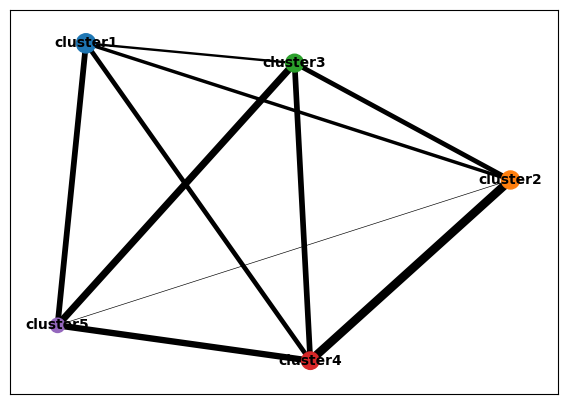

In [32]:
sc.pl.paga(
    adata,
    threshold=0
)

connectivity matrix

In [33]:
paga_conn = adata.uns["paga"]["connectivities"]

paga_df = pd.DataFrame(
    paga_conn.toarray(),
    index=adata.obs["cluster"].cat.categories,
    columns=adata.obs["cluster"].cat.categories
)

paga_df

,cluster1,cluster2,cluster3,cluster4,cluster5
cluster1,0.000000,0.330300,0.229837,0.447793,0.554435
cluster2,0.330300,0.000000,0.459030,0.821272,0.061424
cluster3,0.229837,0.459030,0.000000,0.545084,0.677714
cluster4,0.447793,0.821272,0.545084,0.000000,0.609870
cluster5,0.554435,0.061424,0.677714,0.609870,0.000000


correlate with existing time point information

In [34]:
cluster_time_counts = pd.crosstab(
    adata.obs["cluster"],
    adata.obs["timepoint"]
)

cluster_time_counts

timepoint,0,5,10,15
cluster,,,,
cluster1,13,18,13,17
cluster2,8,12,12,16
cluster3,9,10,14,12
cluster4,6,17,9,10
cluster5,0,2,8,9


In [35]:
cluster_time_fraction = pd.crosstab(
    adata.obs["cluster"],
    adata.obs["timepoint"],
    normalize="index"
)

cluster_time_fraction

timepoint,0,5,10,15
cluster,,,,
cluster1,0.213115,0.295082,0.213115,0.278689
cluster2,0.166667,0.250000,0.250000,0.333333
cluster3,0.200000,0.222222,0.311111,0.266667
cluster4,0.142857,0.404762,0.214286,0.238095
cluster5,0.000000,0.105263,0.421053,0.473684


## CXCL2 DPT root: orient diffusion-manifold endpoints using local 0-min enrichment

Derive two candidate endpoints from chromatin geometry first: find the most separated pair of reads in the first 10 nontrivial diffusion components (`X_diffmap[:, 1:11]`). Column 0 is Scanpy's stationary component and is excluded. Use the coordinates directly, without rescaling or additional eigenvalue weighting. The existing graph and 15-component diffusion-map calculation are unchanged; DPT still uses its original `n_dcs=10`, `n_branchings=0` settings.

For each endpoint, its local neighborhood consists of the endpoint itself plus every read connected to it by one edge in the existing undirected Manhattan kNN graph. Compare the fraction of 0-min reads in those neighborhoods to orient the endpoints. Within the more 0-min-enriched neighborhood, choose the 0-min read closest to that endpoint in diffusion space.

Experimental time enters only after the endpoints and graph neighborhoods have been defined. Leiden labels, TSCAN, and correlations with experimental time do not select the geometry or root. Exact ties in endpoint distances, baseline enrichment, or root distances use the original AnnData row order. If neither neighborhood contains a 0-min read, stop instead of expanding the neighborhoods or substituting a different root rule.

### Compute diffusion geometry before choosing the root

Reuse the existing Manhattan kNN graph and the unchanged 15-component diffusion-map calculation. The endpoint search and subsequent DPT use this same computed geometry.

In [57]:
sc.tl.diffmap(
    adata,
    n_comps=15
)

In [58]:
adata.obsm["X_diffmap"]

array([[ 0.0767683  , -0.10172156 , -0.04789328 , ...,  0.03867171 ,
        -0.025876138,  0.027392035],
       [ 0.06549081 ,  0.08064213 , -0.025294589, ..., -0.09253967 ,
         0.0595094  ,  0.090466276],
       [ 0.08009619 , -0.051784784, -0.06919384 , ..., -0.06936651 ,
        -0.040099874,  0.01134273 ],
       ...,
       [ 0.06646577 ,  0.09695124 ,  0.011227232, ..., -0.027654333,
         0.11093594 ,  0.1458611  ],
       [ 0.08220103 , -0.09369738 ,  0.11822118 , ..., -0.07499015 ,
        -0.012711435,  0.022993436],
       [ 0.050847944,  0.04428266 , -0.009484707, ..., -0.001385004,
        -0.03249244 , -0.027040571]], shape=(215, 15), dtype=float32)

In [59]:
# Geometry only: no experimental-time or Leiden information enters this cell.
from scipy.sparse.csgraph import connected_components

if gene != "CXCL2":
    raise ValueError("This endpoint-root selection is for the existing CXCL2 adata only.")
if not adata.obs_names.is_unique or adata.n_obs < 2:
    raise ValueError("Endpoint selection requires at least two reads with unique RIDs.")

root_connectivity_key = adata.uns["neighbors"]["connectivities_key"]
root_graph = sparse.csr_matrix(adata.obsp[root_connectivity_key])
if root_graph.shape != (adata.n_obs, adata.n_obs):
    raise ValueError("The existing graph must use the same AnnData read order.")
if (root_graph != root_graph.T).nnz or not np.isfinite(root_graph.data).all():
    raise ValueError("Expected the existing finite, undirected Manhattan kNN graph.")
if (root_graph.data < 0).any() or connected_components(root_graph, directed=False)[0] != 1:
    raise ValueError("Endpoint selection requires the original connected affinity graph.")

diffmap_for_root = np.asarray(adata.obsm["X_diffmap"])
if diffmap_for_root.shape[0] != adata.n_obs or diffmap_for_root.shape[1] < 11:
    raise ValueError("Compute at least 11 stored diffusion components before choosing the root.")
root_diffusion_coordinates = diffmap_for_root[:, 1:11]
if not np.isfinite(root_diffusion_coordinates).all():
    raise ValueError("Root-selection diffusion coordinates must be finite.")

root_diffusion_distances = cdist(
    root_diffusion_coordinates, root_diffusion_coordinates, metric="euclidean"
)
endpoint_pair_rows, endpoint_pair_cols = np.triu_indices(adata.n_obs, k=1)
endpoint_pair_distances = root_diffusion_distances[endpoint_pair_rows, endpoint_pair_cols]
farthest_pair_position = int(np.argmax(endpoint_pair_distances))
endpoint_separation = float(endpoint_pair_distances[farthest_pair_position])
if endpoint_separation <= 0:
    raise ValueError("The diffusion coordinates do not define two distinct endpoints.")

endpoint_labels = ["A", "B"]
endpoint_indices = np.array([
    endpoint_pair_rows[farthest_pair_position], endpoint_pair_cols[farthest_pair_position]
], dtype=int)
endpoint_rids = adata.obs_names[endpoint_indices]
endpoint_neighborhoods = {
    label: np.unique(np.r_[idx, root_graph.getrow(int(idx)).nonzero()[1]])
    for label, idx in zip(endpoint_labels, endpoint_indices)
}
for label, rid in zip(endpoint_labels, endpoint_rids):
    print(f"Candidate endpoint {label} RID: {rid}")
print(f"Endpoint separation in diffusion space: {endpoint_separation:.6f}")
print("Neighborhood rule: endpoint plus all directly connected Manhattan-graph neighbors.")

Candidate endpoint A RID: m84241_260613_020346_s3/147263396/ccs
Candidate endpoint B RID: m84241_260614_140027_s4/179638640/ccs
Endpoint separation in diffusion space: 0.557554
Neighborhood rule: endpoint plus all directly connected Manhattan-graph neighbors.


In [60]:
# Metadata is consulted only after both endpoints and their neighborhoods are fixed.
root_time_levels = [0, 5, 10, 15]
root_timepoints = pd.to_numeric(adata.obs["timepoint"], errors="raise").to_numpy()
if not np.isin(root_timepoints, root_time_levels).all():
    raise ValueError("Every CXCL2 read must have experimental time 0, 5, 10, or 15 min.")

endpoint_time_counts = pd.DataFrame(
    [[int(np.count_nonzero(root_timepoints[endpoint_neighborhoods[label]] == timepoint))
      for timepoint in root_time_levels] for label in endpoint_labels],
    index=pd.Index(endpoint_labels, name="endpoint"),
    columns=pd.Index(root_time_levels, name="timepoint_min")
)
endpoint_neighborhood_sizes = endpoint_time_counts.sum(axis=1)
endpoint_time_fractions = endpoint_time_counts.div(endpoint_neighborhood_sizes, axis=0)

print("Endpoint-neighborhood read counts by experimental time:")
print(endpoint_time_counts.assign(total=endpoint_neighborhood_sizes).to_string())
print("Endpoint-neighborhood fractions by experimental time:")
print(endpoint_time_fractions.to_string(float_format=lambda value: f"{value:.4f}"))

Endpoint-neighborhood read counts by experimental time:
timepoint_min  0  5  10  15  total
endpoint                          
A              3  3   5   4     15
B              1  7   2   1     11
Endpoint-neighborhood fractions by experimental time:
timepoint_min     0      5      10     15
endpoint                                 
A             0.2000 0.2000 0.3333 0.2667
B             0.0909 0.6364 0.1818 0.0909


### Select the baseline endpoint and its nearest 0-min representative

Orient using the larger **within-neighborhood fraction** of 0-min reads, rather than the absolute count. Select the nearest 0-min read to that endpoint using the same ten-dimensional Euclidean distances. These choices do not optimize DPT's correlation with experimental time or any other trajectory. Equal enrichment is reported explicitly and resolved by the first endpoint in AnnData row order.

In [61]:
baseline_fractions = endpoint_time_fractions[0].to_numpy()
if baseline_fractions.max() <= 0:
    raise ValueError(
        "Neither endpoint neighborhood contains a 0-min read; the specified baseline "
        "orientation rule cannot select a root. Neighborhoods have not been expanded."
    )
baseline_endpoint_position = int(np.argmax(baseline_fractions))
if np.count_nonzero(baseline_fractions == baseline_fractions.max()) > 1:
    print("WARNING: Equal 0-min enrichment; using the first endpoint in AnnData row order.")
baseline_endpoint_label = endpoint_labels[baseline_endpoint_position]
baseline_endpoint_idx = int(endpoint_indices[baseline_endpoint_position])
baseline_endpoint_rid = adata.obs_names[baseline_endpoint_idx]

baseline_neighborhood = endpoint_neighborhoods[baseline_endpoint_label]
root_candidate_indices = baseline_neighborhood[root_timepoints[baseline_neighborhood] == 0]
root_candidate_distances = root_diffusion_distances[
    baseline_endpoint_idx, root_candidate_indices
]
root_idx = int(root_candidate_indices[int(np.argmin(root_candidate_distances))])
root_rid = adata.obs_names[root_idx]
root_endpoint_distance = float(root_diffusion_distances[baseline_endpoint_idx, root_idx])
adata.uns["iroot"] = root_idx

print(f"Selected baseline endpoint: {baseline_endpoint_label} ({baseline_endpoint_rid})")
print(f"Baseline-neighborhood 0-min fraction: {baseline_fractions[baseline_endpoint_position]:.6f}")
print(f"Number of 0-min candidates in that neighborhood: {len(root_candidate_indices)}")
print(f"Selected root RID: {root_rid}")
print(f"AnnData row index of root: {root_idx}")
print(f"Root diffusion-space distance from endpoint: {root_endpoint_distance:.6f}")

Selected baseline endpoint: A (m84241_260613_020346_s3/147263396/ccs)
Baseline-neighborhood 0-min fraction: 0.200000
Number of 0-min candidates in that neighborhood: 3
Selected root RID: m84241_260614_075102_s1/131270762/ccs
AnnData row index of root: 131
Root diffusion-space distance from endpoint: 0.036008


1. run diffusion time analysis

In [62]:
sc.tl.dpt(
    adata,
    n_dcs=10,
    n_branchings=0
)

In [63]:
adata.obs[
    ["cluster", "timepoint", "dpt_pseudotime"]
].head(20)

,cluster,timepoint,dpt_pseudotime
RID,,,
m84241_260505_182714_s3/120329826/ccs,cluster1,5,0.775582
m84241_260505_182714_s3/141432141/ccs,cluster2,10,0.580767
m84241_260505_182714_s3/149425764/ccs,cluster1,5,0.741583
m84241_260505_182714_s3/154011751/ccs,cluster4,5,0.623753
m84241_260505_182714_s3/165874152/ccs,cluster3,10,0.598015
m84241_260505_182714_s3/181602117/ccs,cluster4,10,0.358127
m84241_260505_182714_s3/192546611/ccs,cluster1,10,1.000000
m84241_260505_182714_s3/21103640/ccs,cluster2,5,0.735959
m84241_260505_182714_s3/228066721/ccs,cluster4,5,0.532162


#### Pseudotime against time point information

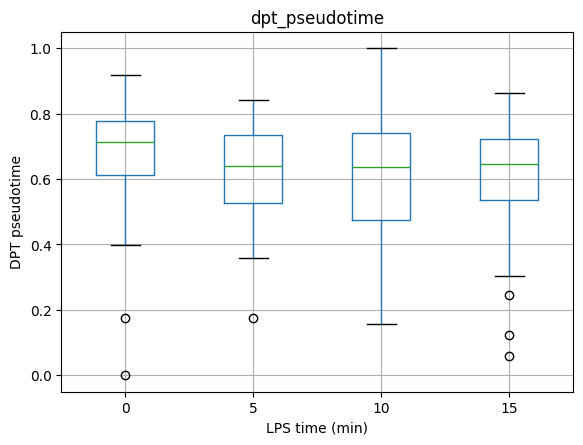

In [64]:
adata.obs.boxplot(
    column="dpt_pseudotime",
    by="timepoint"
)

plt.xlabel("LPS time (min)")
plt.ylabel("DPT pseudotime")
plt.suptitle("")
plt.show()

### Compute UMAP from the existing Manhattan graph before PAGA comparisons

`paga_compare(basis="umap")` needs `adata.obsm["X_umap"]`; it does not compute the embedding. Generate this display from the existing graph, initialized with the existing PAGA layout and a fixed random seed. `use_rep="X"` identifies the original binary m6A features and prevents Scanpy from automatically computing PCA. No neighbors, diffusion geometry, or DPT scores are recalculated.

Scanpy may warn that the connectivities were not computed using UMAP. That is expected here: the saved Manhattan graph is deliberately reused.

In [ ]:
#reuse the original Manhattan connectivities and binary matrix.
adata.uns["neighbors"]["params"]["use_rep"] = "X"
sc.tl.umap(
    adata,
    neighbors_key="neighbors",
    init_pos="paga",
    random_state=0
)


/project/spott/cshan/envs/Jupyter-notebook/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


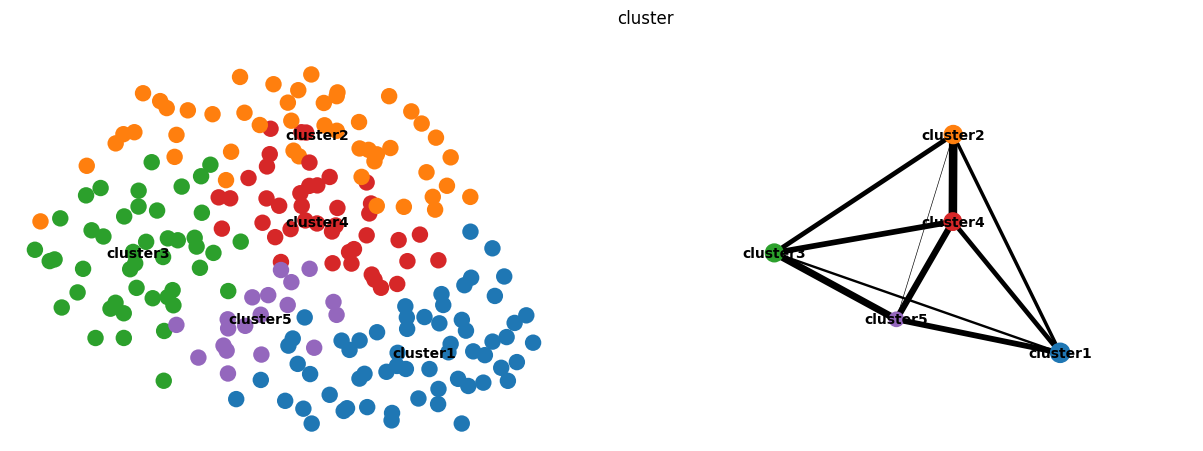

[<Axes: xlabel='UMAP1', ylabel='UMAP2'>, <Axes: >]

In [66]:
sc.pl.paga_compare(
    adata,
    basis="umap",
    color="cluster",
    threshold=0.05
)

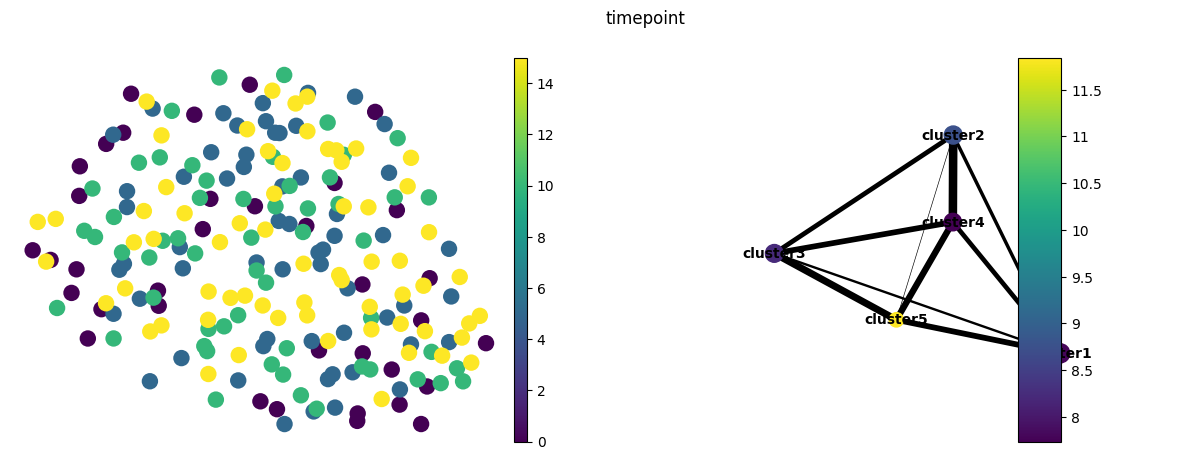

[<Axes: xlabel='UMAP1', ylabel='UMAP2'>, <Axes: >]

In [67]:
sc.pl.paga_compare(
    adata,
    basis="umap",
    color="timepoint",
    threshold=0.05
)

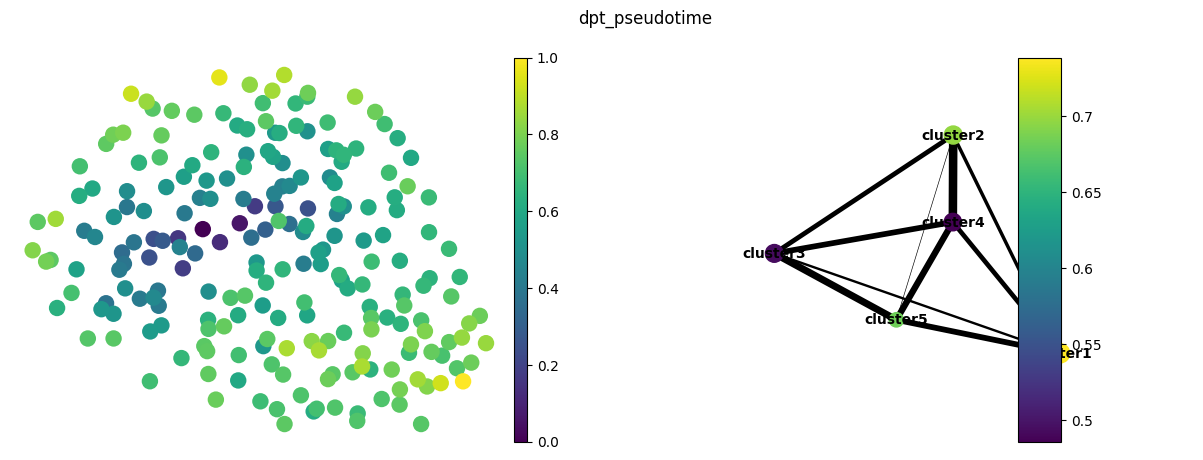

[<Axes: xlabel='UMAP1', ylabel='UMAP2'>, <Axes: >]

In [68]:
sc.pl.paga_compare(
    adata,
    basis="umap",
    color="dpt_pseudotime",
    threshold=0.05
)

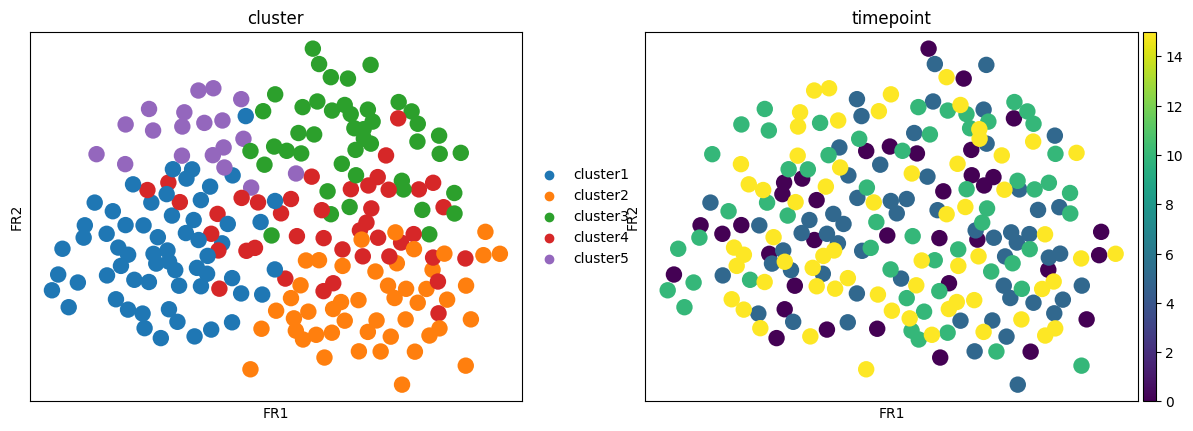

In [69]:
sc.tl.draw_graph(
    adata,
    init_pos="paga"
)

sc.pl.draw_graph(
    adata,
    color=["cluster", "timepoint"]
)

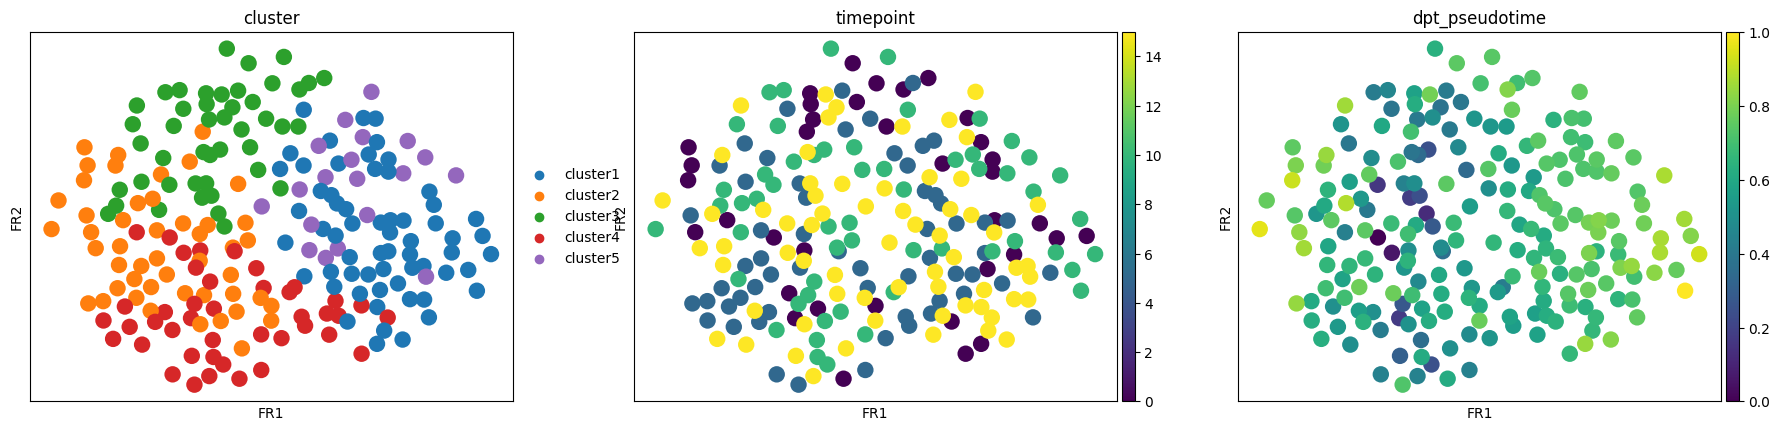

In [27]:
sc.pl.draw_graph(
    adata,
    color=["cluster", "timepoint", "dpt_pseudotime"]
)

<Axes: title={'center': 'dpt_pseudotime'}, xlabel='cluster'>

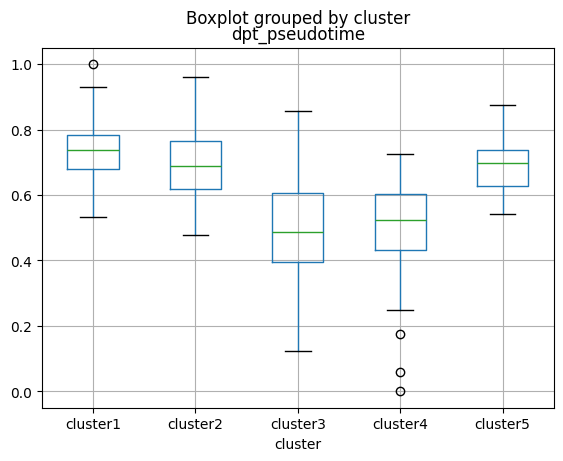

In [28]:
adata.obs.boxplot(
    column="dpt_pseudotime",
    by="cluster"
)

## CXCL2: cluster-level DPT summaries

Use the existing CXCL2 `adata`, Leiden clusters, and 0-min representative of the diffusion endpoint oriented as baseline. This section does not rerun clustering, graph construction, PAGA, diffusion maps, or DPT. The original per-read `dpt_pseudotime` is retained. The existing PAGA network above describes connections between clusters without specifying a biological path.

Median DPT summarizes each cluster while the boxplots retain its full within-cluster distribution. Experimental time is used to summarize composition and evaluate association. All correlations below give each cluster one observation. Cluster ordering in the displays does not modify the scores or establish a biological sequence.

In [70]:
from scipy.stats import spearmanr
from IPython.display import display

if gene != "CXCL2":
    raise ValueError("This cluster-level DPT section is for the existing CXCL2 adata only.")

required_obs = {"cluster", "timepoint", "dpt_pseudotime"}
if not required_obs.issubset(adata.obs.columns):
    raise ValueError(f"Missing observation fields: {required_obs - set(adata.obs.columns)}")
if not isinstance(adata.obs["cluster"].dtype, pd.CategoricalDtype):
    raise ValueError("Categorical Leiden cluster assignments are required for these summaries.")

cxcl2_obs = adata.obs[["cluster", "timepoint", "dpt_pseudotime"]].copy()
cxcl2_timepoints = [0, 5, 10, 15]
cxcl2_obs["timepoint"] = pd.to_numeric(cxcl2_obs["timepoint"], errors="raise")
if cxcl2_obs["cluster"].isna().any() or not cxcl2_obs["timepoint"].isin(cxcl2_timepoints).all():
    raise ValueError("Each read must have a cluster and an experimental time of 0, 5, 10, or 15 min.")

cluster_summary = cxcl2_obs.groupby("cluster", observed=True).agg(
    cluster_dpt_pseudotime=("dpt_pseudotime", "median"),
    mean_dpt_pseudotime=("dpt_pseudotime", "mean"),
    n_reads=("dpt_pseudotime", "size"),
    mean_real_time=("timepoint", "mean"),
    median_real_time=("timepoint", "median")
)
cluster_timepoint_fractions = (
    pd.crosstab(cxcl2_obs["cluster"], cxcl2_obs["timepoint"])
    .reindex(index=cluster_summary.index, columns=cxcl2_timepoints, fill_value=0)
    .div(cluster_summary["n_reads"], axis=0)
)
cluster_timepoint_fractions.columns = [f"fraction_{t}_min" for t in cxcl2_timepoints]
timepoint_fraction_columns = cluster_timepoint_fractions.columns.tolist()
cluster_summary = cluster_summary.join(cluster_timepoint_fractions).sort_values(
    "cluster_dpt_pseudotime", kind="stable"
)

print("CXCL2 cluster summary, ordered by median DPT:")
print(cluster_summary.to_string(float_format=lambda value: f"{value:.4f}"))
display(cluster_summary)

CXCL2 cluster summary, ordered by median DPT:
          cluster_dpt_pseudotime  mean_dpt_pseudotime  n_reads  mean_real_time  median_real_time  fraction_0_min  fraction_5_min  fraction_10_min  fraction_15_min
cluster                                                                                                                                                           
cluster3                  0.4884               0.4933       45          8.2222           10.0000          0.2000          0.2222           0.3111           0.2667
cluster4                  0.5234               0.4860       42          7.7381            5.0000          0.1429          0.4048           0.2143           0.2381
cluster2                  0.6900               0.6973       48          8.7500           10.0000          0.1667          0.2500           0.2500           0.3333
cluster5                  0.6968               0.6829       19         11.8421           10.0000          0.0000          0.1053           

,cluster_dpt_pseudotime,mean_dpt_pseudotime,n_reads,mean_real_time,median_real_time,fraction_0_min,fraction_5_min,fraction_10_min,fraction_15_min
cluster,,,,,,,,,
cluster3,0.488442,0.493334,45,8.222222,10.0,0.200000,0.222222,0.311111,0.266667
cluster4,0.523438,0.486004,42,7.738095,5.0,0.142857,0.404762,0.214286,0.238095
cluster2,0.690020,0.697308,48,8.750000,10.0,0.166667,0.250000,0.250000,0.333333
cluster5,0.696780,0.682930,19,11.842105,10.0,0.000000,0.105263,0.421053,0.473684
cluster1,0.736156,0.738142,61,7.786885,5.0,0.213115,0.295082,0.213115,0.278689


### Cluster median DPT versus experimental time

With only a few CXCL2 clusters, the effect direction and cluster ordering are more informative than the p-value alone. Point area is proportional to the number of reads, but the Spearman correlation weights clusters equally.

Cluster median DPT vs mean experimental time (5 clusters)
Spearman rho: 0.2000
p-value: 0.74706


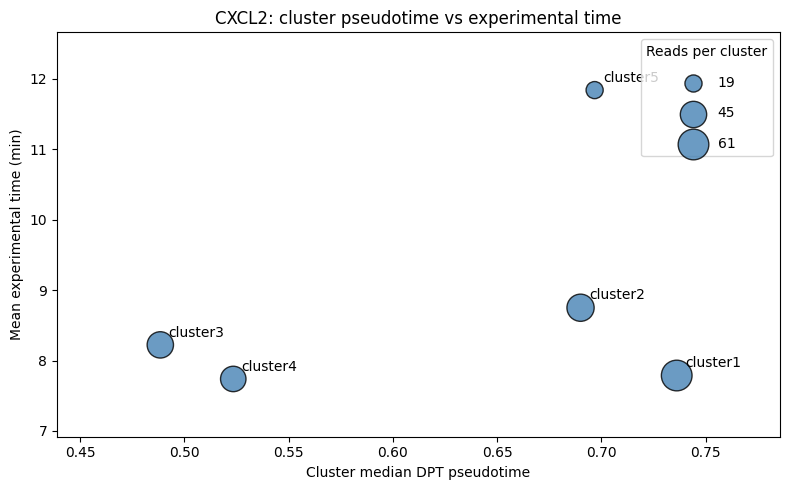

In [71]:
def report_cluster_time_spearman(table, score_column, label):
    paired = table[[score_column, "mean_real_time"]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(paired) < 2 or (paired.nunique() < 2).any():
        rho, p_value = np.nan, np.nan
        print(f"WARNING: {label} correlation requires at least two clusters and nonconstant values.")
    else:
        rho, p_value = spearmanr(paired[score_column], paired["mean_real_time"])
    # With few clusters, effect direction and cluster ordering matter more than p alone.
    print(f"{label} vs mean experimental time ({len(paired)} clusters)")
    print(f"Spearman rho: {rho:.4f}")
    print(f"p-value: {p_value:.6g}")
    return rho, p_value


def plot_cluster_time_score(table, score_column, xlabel, title):
    plotted = table.replace([np.inf, -np.inf], np.nan).dropna(subset=[score_column, "mean_real_time"])
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(
        plotted[score_column], plotted["mean_real_time"],
        s=plotted["n_reads"] * 8, color="steelblue", edgecolor="black", alpha=0.8
    )
    for cluster, values in plotted.iterrows():
        ax.annotate(str(cluster), (values[score_column], values["mean_real_time"]),
                    xytext=(6, 6), textcoords="offset points")
    if not plotted.empty:
        legend_counts = sorted({int(plotted["n_reads"].min()),
                                int(plotted["n_reads"].median()),
                                int(plotted["n_reads"].max())})
        for count in legend_counts:
            ax.scatter([], [], s=count * 8, color="steelblue", edgecolor="black",
                       alpha=0.8, label=str(count))
        ax.legend(title="Reads per cluster", loc="best", labelspacing=1.2)
    ax.set(xlabel=xlabel, ylabel="Mean experimental time (min)", title=title)
    ax.margins(x=0.2, y=0.2)
    fig.tight_layout()
    plt.show()


cluster_dpt_spearman_rho, cluster_dpt_spearman_pvalue = report_cluster_time_spearman(
    cluster_summary, "cluster_dpt_pseudotime", "Cluster median DPT"
)
plot_cluster_time_score(
    cluster_summary, "cluster_dpt_pseudotime", "Cluster median DPT pseudotime",
    "CXCL2: cluster pseudotime vs experimental time"
)

### Read-level annotations and within-cluster DPT percentile

`dpt_pseudotime` is the original individual-read DPT; `cluster_dpt_pseudotime` is its cluster's median DPT.

For `within_cluster_dpt_percentile`, calculate average ranks within each cluster and rescale the minimum and maximum ranks to 0 and 1. Ties receive the same percentile. Singleton or constant-DPT clusters receive 0 by convention; missing DPT values remain NaN. Keep this percentile separate from the original DPT, which is used for the heatmap's within-cluster ordering and point annotation.

In [31]:
# Map by cluster label; never overwrite the original individual-read DPT.
adata.obs["cluster_dpt_pseudotime"] = (
    adata.obs["cluster"].map(cluster_summary["cluster_dpt_pseudotime"]).astype(float)
)
within_cluster_dpt_ranks = adata.obs.groupby("cluster", observed=True)["dpt_pseudotime"].rank(
    method="average", na_option="keep"
)
within_cluster_rank_groups = within_cluster_dpt_ranks.groupby(adata.obs["cluster"], observed=True)
within_cluster_min_rank = within_cluster_rank_groups.transform("min")
within_cluster_rank_span = within_cluster_rank_groups.transform("max") - within_cluster_min_rank
adata.obs["within_cluster_dpt_percentile"] = (
    (within_cluster_dpt_ranks - within_cluster_min_rank)
    / within_cluster_rank_span.replace(0, np.nan)
).mask(within_cluster_rank_span.eq(0) & within_cluster_dpt_ranks.notna(), 0.0)

display(adata.obs[
    ["cluster", "timepoint", "dpt_pseudotime", "cluster_dpt_pseudotime",
     "within_cluster_dpt_percentile"]
].head())

,cluster,timepoint,dpt_pseudotime,cluster_dpt_pseudotime,within_cluster_dpt_percentile
RID,,,,,
m84241_260505_182714_s3/120329826/ccs,cluster1,5,0.775582,0.736156,0.716667
m84241_260505_182714_s3/141432141/ccs,cluster2,10,0.580767,0.690020,0.106383
m84241_260505_182714_s3/149425764/ccs,cluster1,5,0.741583,0.736156,0.566667
m84241_260505_182714_s3/154011751/ccs,cluster4,5,0.623753,0.523438,0.853659
m84241_260505_182714_s3/165874152/ccs,cluster3,10,0.598015,0.488442,0.727273


### comparisons of read-level and cluster-level DPT

Cluster median DPT is repeated for each read in the corresponding boxplot, so its distribution by experimental time reflects cluster composition. These repeated values do not add independent trajectory measurements. The read-level boxplots retain the original within-cluster variation; clusters are displayed in median DPT order.

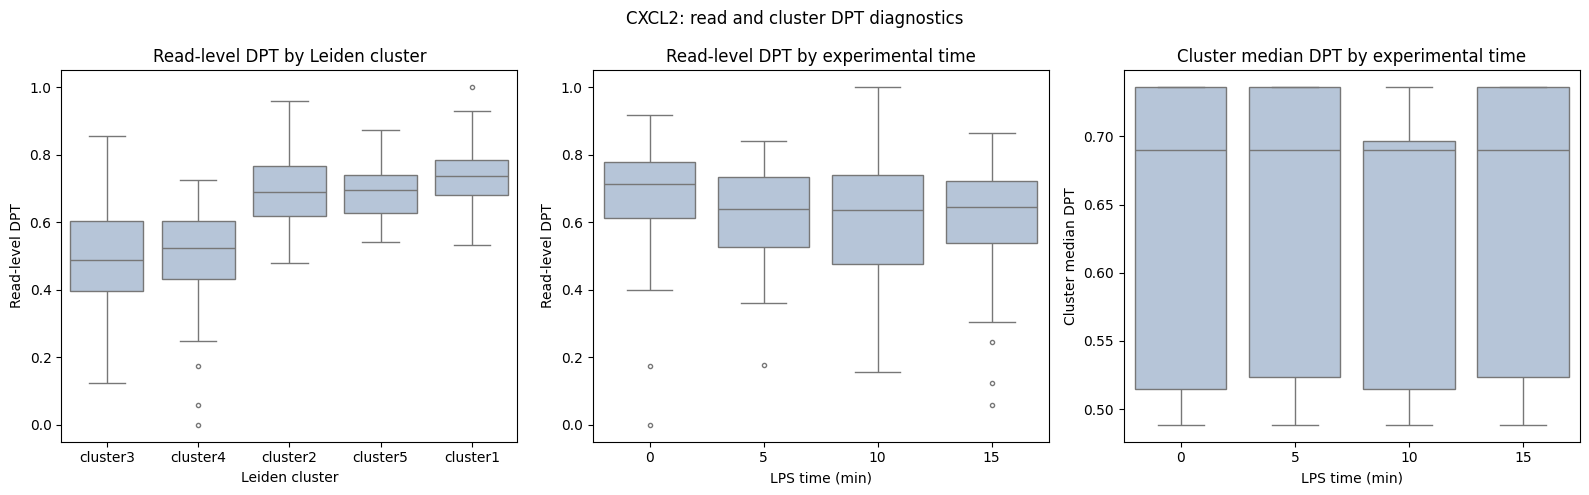

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.boxplot(
    data=adata.obs, x="cluster", y="dpt_pseudotime",
    order=cluster_summary.index.tolist(), color="lightsteelblue", fliersize=3, ax=axes[0]
)
axes[0].set(title="Read-level DPT by Leiden cluster", xlabel="Leiden cluster", ylabel="Read-level DPT")
for ax, column, title, ylabel in [
    (axes[1], "dpt_pseudotime", "Read-level DPT by experimental time", "Read-level DPT"),
    (axes[2], "cluster_dpt_pseudotime", "Cluster median DPT by experimental time", "Cluster median DPT")
]:
    sns.boxplot(data=adata.obs, x="timepoint", y=column, order=cxcl2_timepoints,
                color="lightsteelblue", fliersize=3, ax=ax)
    ax.set(title=title, xlabel="LPS time (min)", ylabel=ylabel)
fig.suptitle("CXCL2: read and cluster DPT diagnostics")
fig.tight_layout()
plt.show()

### Experimental-time composition by Leiden cluster

Display clusters in median DPT order. This is a display choice, not an inferred biological path. Each bar contains the within-cluster fractions at 0, 5, 10, and 15 min.

Cluster composition displayed in median DPT order; this does not specify a biological path.


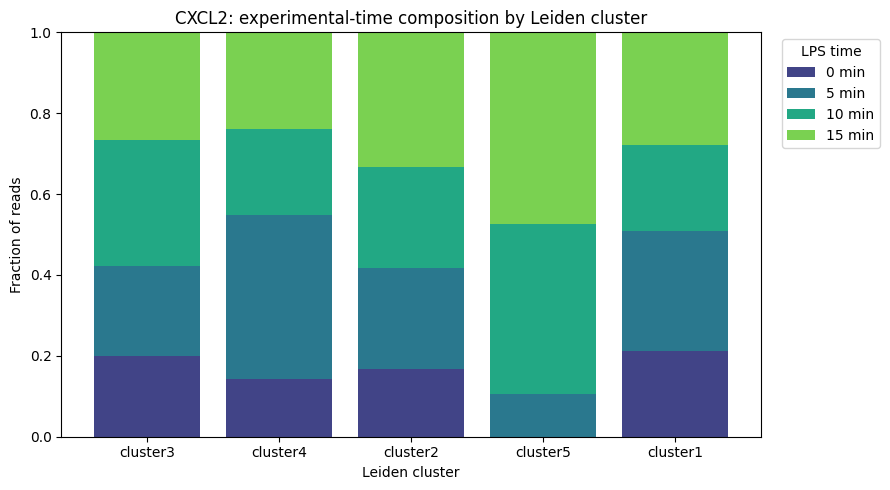

In [73]:
cluster_display_order = cluster_summary.sort_values(
    "cluster_dpt_pseudotime", kind="stable"
).index
print("Cluster composition displayed in median DPT order; this does not specify a biological path.")

cluster_composition = cluster_summary.loc[cluster_display_order, timepoint_fraction_columns].copy()
cluster_composition.columns = [f"{t} min" for t in cxcl2_timepoints]
ax = cluster_composition.plot.bar(
    stacked=True, figsize=(9, 5), width=0.8, color=sns.color_palette("viridis", 4), rot=0
)
ax.set(xlabel="Leiden cluster", ylabel="Fraction of reads", ylim=(0, 1),
       title="CXCL2: experimental-time composition by Leiden cluster")
ax.legend(title="LPS time", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.figure.tight_layout()
plt.show()

### CXCL2: m6A heatmap with cluster and DPT annotations

Group reads by their existing Leiden cluster, display cluster blocks in median DPT order, and sort reads within each block by their original individual-read DPT. Cluster grouping and block order are display choices, not an inferred biological path; the AnnData row order and all DPT values remain unchanged.

Align categorical cluster and experimental-time strips and a DPT point annotation with every heatmap row. DPT uses the same original 0–1 scale across clusters. Horizontal lines mark cluster boundaries. All panels use the same row permutation, and the heatmap retains all original site-level m6A features. Experimental time is an annotation only and does not enter the sorting.

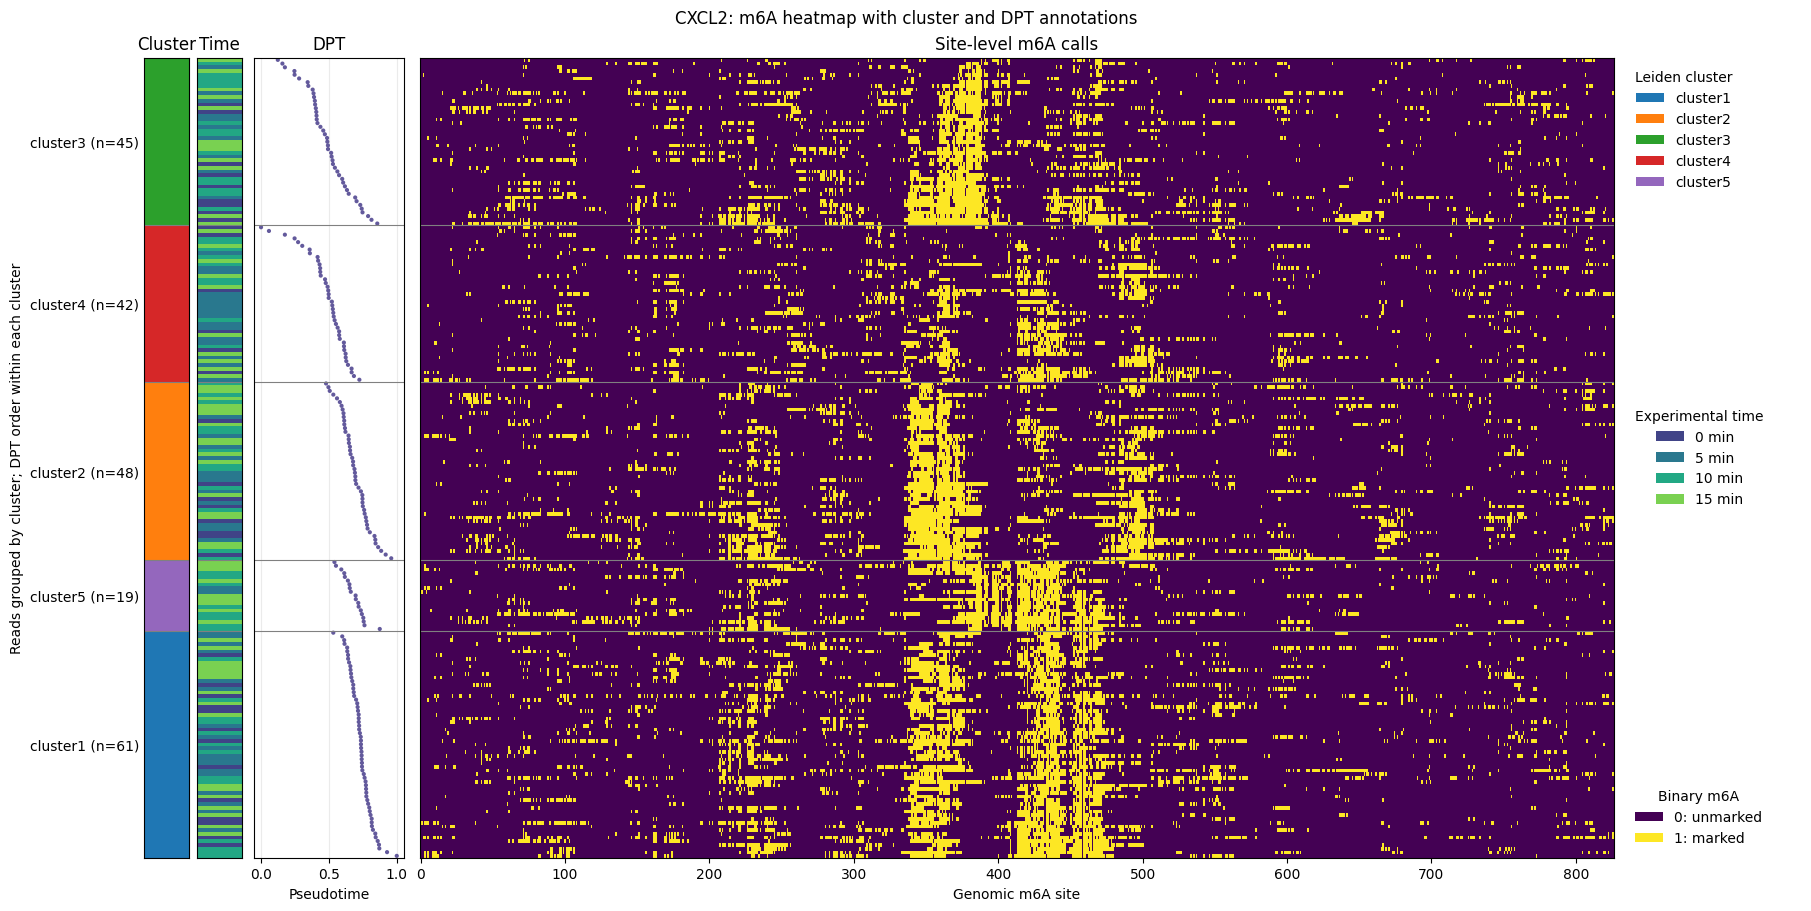

In [74]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

if gene != "CXCL2":
    raise ValueError("This annotated heatmap is for the existing CXCL2 adata only.")
heatmap_pseudotime = adata.obs["dpt_pseudotime"].to_numpy()
heatmap_clusters = adata.obs["cluster"].astype("category")
heatmap_timepoints = [0, 5, 10, 15]
heatmap_times = pd.to_numeric(adata.obs["timepoint"], errors="raise")
if adata.n_obs == 0 or not np.isfinite(heatmap_pseudotime).all():
    raise ValueError("The annotated heatmap requires reads with finite DPT pseudotime.")
if heatmap_clusters.isna().any():
    raise ValueError("Each heatmap read must have a Leiden cluster annotation.")
if not heatmap_times.isin(heatmap_timepoints).all():
    raise ValueError("Each heatmap read must have an experimental time of 0, 5, 10, or 15 min.")

# Display order only: cluster median DPT, then original read DPT within each cluster.
heatmap_cluster_order = (
    adata.obs.groupby("cluster", observed=True)["dpt_pseudotime"]
    .median().sort_values(kind="stable").index
)
heatmap_order = np.concatenate([
    np.flatnonzero(heatmap_clusters.eq(cluster).to_numpy())[
        np.argsort(
            heatmap_pseudotime[heatmap_clusters.eq(cluster).to_numpy()], kind="stable"
        )
    ]
    for cluster in heatmap_cluster_order
])
# Apply one permutation to the matrix and every annotation; do not reorder adata.
heatmap_X_ordered = adata.X[heatmap_order, :]
heatmap_X_ordered = (
    heatmap_X_ordered.toarray() if sparse.issparse(heatmap_X_ordered)
    else np.asarray(heatmap_X_ordered)
)
heatmap_dpt_ordered = heatmap_pseudotime[heatmap_order]
heatmap_cluster_codes = heatmap_clusters.cat.codes.to_numpy()[heatmap_order]
heatmap_cluster_names = heatmap_clusters.cat.categories
heatmap_time_codes = pd.Categorical(
    heatmap_times, categories=heatmap_timepoints, ordered=True
).codes[heatmap_order]
heatmap_read_rows = np.arange(adata.n_obs)
heatmap_block_counts = (
    heatmap_clusters.value_counts().reindex(heatmap_cluster_order).to_numpy()
)
heatmap_block_ends = np.cumsum(heatmap_block_counts)
heatmap_block_starts = np.r_[0, heatmap_block_ends[:-1]]
heatmap_block_centers = (heatmap_block_starts + heatmap_block_ends - 1) / 2
heatmap_boundaries = heatmap_block_ends[:-1] - 0.5

# Reuse the existing Scanpy cluster colors in categorical order.
heatmap_cluster_colors = adata.uns.get("cluster_colors")
if heatmap_cluster_colors is None or len(heatmap_cluster_colors) != len(heatmap_cluster_names):
    heatmap_cluster_colors = sns.color_palette("husl", len(heatmap_cluster_names))
heatmap_time_colors = sns.color_palette("viridis", len(heatmap_timepoints))

annotated_heatmap_fig = plt.figure(figsize=(18, 9), layout="constrained")
heatmap_grid = annotated_heatmap_fig.add_gridspec(
    1, 5, width_ratios=[0.45, 0.45, 1.5, 12, 1.8]
)
heatmap_cluster_ax = annotated_heatmap_fig.add_subplot(heatmap_grid[0, 0])
heatmap_time_ax = annotated_heatmap_fig.add_subplot(heatmap_grid[0, 1], sharey=heatmap_cluster_ax)
heatmap_dpt_ax = annotated_heatmap_fig.add_subplot(heatmap_grid[0, 2], sharey=heatmap_cluster_ax)
heatmap_matrix_ax = annotated_heatmap_fig.add_subplot(heatmap_grid[0, 3], sharey=heatmap_cluster_ax)
heatmap_legend_ax = annotated_heatmap_fig.add_subplot(heatmap_grid[0, 4])

heatmap_cluster_ax.imshow(
    heatmap_cluster_codes[:, None], aspect="auto", interpolation="nearest", origin="upper",
    cmap=ListedColormap(heatmap_cluster_colors), vmin=-0.5, vmax=len(heatmap_cluster_names) - 0.5
)
heatmap_cluster_ax.set(title="Cluster", xticks=[], ylabel="Reads grouped by cluster; DPT order within each cluster")
heatmap_cluster_ax.set_yticks(heatmap_block_centers)
heatmap_cluster_ax.set_yticklabels([
    f"{cluster} (n={count})" for cluster, count in zip(heatmap_cluster_order, heatmap_block_counts)
])
heatmap_cluster_ax.tick_params(axis="y", length=0)

heatmap_time_ax.imshow(
    heatmap_time_codes[:, None], aspect="auto", interpolation="nearest", origin="upper",
    cmap=ListedColormap(heatmap_time_colors), vmin=-0.5, vmax=len(heatmap_timepoints) - 0.5
)
heatmap_time_ax.set(title="Time", xticks=[])
heatmap_time_ax.tick_params(axis="y", left=False, labelleft=False)

heatmap_dpt_ax.scatter(
    heatmap_dpt_ordered, heatmap_read_rows, s=9, color="darkslateblue", edgecolors="none", alpha=0.85
)
heatmap_dpt_ax.set(title="DPT", xlabel="Pseudotime", xlim=(-0.05, 1.05), xticks=[0, 0.5, 1])
heatmap_dpt_ax.grid(axis="x", alpha=0.25)
heatmap_dpt_ax.set_axisbelow(True)
heatmap_dpt_ax.tick_params(axis="y", left=False, labelleft=False)

heatmap_image = heatmap_matrix_ax.imshow(
    heatmap_X_ordered, aspect="auto", interpolation="nearest", origin="upper",
    cmap="viridis", vmin=0, vmax=1
)
heatmap_matrix_ax.set(xlabel="Genomic m6A site", title="Site-level m6A calls")
heatmap_matrix_ax.tick_params(axis="y", left=False, labelleft=False)
for heatmap_ax in [heatmap_cluster_ax, heatmap_time_ax, heatmap_dpt_ax, heatmap_matrix_ax]:
    for heatmap_boundary in heatmap_boundaries:
        heatmap_ax.axhline(heatmap_boundary, color="gray", linewidth=0.8)
heatmap_cluster_ax.set_ylim(adata.n_obs - 0.5, -0.5)

heatmap_legend_ax.axis("off")
heatmap_cluster_legend = heatmap_legend_ax.legend(
    handles=[Patch(facecolor=color, label=str(cluster))
             for cluster, color in zip(heatmap_cluster_names, heatmap_cluster_colors)],
    title="Leiden cluster", loc="upper left", frameon=False
)
heatmap_legend_ax.add_artist(heatmap_cluster_legend)
heatmap_time_legend = heatmap_legend_ax.legend(
    handles=[Patch(facecolor=color, label=f"{timepoint} min")
             for timepoint, color in zip(heatmap_timepoints, heatmap_time_colors)],
    title="Experimental time", loc="center left", frameon=False
)
heatmap_legend_ax.add_artist(heatmap_time_legend)
heatmap_legend_ax.legend(
    handles=[Patch(facecolor=heatmap_image.cmap(0.0), label="0: unmarked"),
             Patch(facecolor=heatmap_image.cmap(1.0), label="1: marked")],
    title="Binary m6A", loc="lower left", frameon=False
)
annotated_heatmap_fig.suptitle("CXCL2: m6A heatmap with cluster and DPT annotations")
plt.show()

## Additional read-level CXCL2 DPT plots

These plots use the current endpoint-rooted DPT scores and all original CXCL2 reads/sites. They do not alter the graph, root, pseudotime, cluster labels, or AnnData row order. Here accessibility is the **fraction of original sites marked with m6A per read** (sum of binary calls / 827), a read-level accessibility proxy, not CpG methylation.

The two figures are displayed inline and saved **only as PDFs** under macrophage_project/pseudotime/DPT_CXCL2/figures. All plotting tables remain in memory.

In [23]:
# Prepare plotting copies and verify matrix/metadata correspondence strictly by RID.
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter
from statsmodels.nonparametric.smoothers_lowess import lowess

if gene != "CXCL2" or not adata.obs_names.is_unique:
    raise ValueError("These plots require the existing CXCL2 object with unique RIDs.")
dpt_plot_X = adata.X.toarray() if sparse.issparse(adata.X) else np.asarray(adata.X)
if dpt_plot_X.shape != (215, 827) or not np.isin(dpt_plot_X, [0, 1]).all():
    raise ValueError("Expected all 215 reads and 827 original binary m6A sites.")
dpt_source_features = cluster_results["CXCL2"]["features"].set_index("RID")
if (not dpt_source_features.index.is_unique
        or set(dpt_source_features.index) != set(adata.obs_names)):
    raise ValueError("The original feature table and AnnData must contain the same RIDs.")
if not np.array_equal(
    dpt_plot_X, dpt_source_features.loc[adata.obs_names, adata.var_names].to_numpy()
):
    raise ValueError("AnnData's binary matrix does not match the original features by RID/site.")

dpt_plot_obs = adata.obs[["cluster", "timepoint", "dpt_pseudotime"]].copy().reset_index(drop=True)
dpt_plot_obs["RID"] = adata.obs_names.to_numpy()
dpt_plot_obs["timepoint"] = pd.to_numeric(dpt_plot_obs["timepoint"], errors="raise")
dpt_plot_obs["mean_m6a"] = dpt_plot_X.mean(axis=1, dtype=np.float64)
dpt_plot_time_levels = [0, 5, 10, 15]
if (not np.isfinite(dpt_plot_obs["dpt_pseudotime"]).all()
        or not dpt_plot_obs["dpt_pseudotime"].between(0, 1).all()
        or dpt_plot_obs["cluster"].isna().any()
        or not dpt_plot_obs["timepoint"].isin(dpt_plot_time_levels).all()):
    raise ValueError("Every read needs finite DPT, a Leiden label, and a valid timepoint.")
dpt_source_metadata = dpt_source_features.loc[adata.obs_names]
if (not np.array_equal(dpt_plot_obs["cluster"].astype(str),
                       dpt_source_metadata["cluster"].astype(str))
        or not np.array_equal(dpt_plot_obs["timepoint"],
                              pd.to_numeric(dpt_source_metadata["timepoint"]))):
    raise ValueError("Plot metadata do not match the original feature table by RID.")

dpt_plot_clusters = dpt_plot_obs["cluster"].astype("category")
dpt_plot_cluster_levels = list(dpt_plot_clusters.cat.categories)
dpt_plot_cluster_colors = adata.uns.get("cluster_colors")
if (dpt_plot_cluster_colors is None
        or len(dpt_plot_cluster_colors) != len(dpt_plot_cluster_levels)):
    dpt_plot_cluster_colors = sns.color_palette("husl", len(dpt_plot_cluster_levels))
dpt_plot_cluster_palette = dict(zip(dpt_plot_cluster_levels, dpt_plot_cluster_colors))
dpt_plot_time_colors = sns.color_palette("viridis", len(dpt_plot_time_levels))
dpt_binary_colors = ["#F4F4F4", "#283E73"]

# Display permutation only; clusters and timepoints never determine row order.
dpt_global_heatmap_rids = dpt_plot_obs.sort_values(
    ["dpt_pseudotime", "RID"], kind="stable"
)["RID"].to_numpy()
dpt_global_heatmap_order = adata.obs_names.get_indexer(dpt_global_heatmap_rids)
assert np.array_equal(np.sort(dpt_global_heatmap_order), np.arange(adata.n_obs))
assert np.all(np.diff(dpt_plot_obs["dpt_pseudotime"].to_numpy()[dpt_global_heatmap_order]) >= 0)

# cluster_dir is the existing .../macrophage_project/.../TSS_1000 input directory.
dpt_figure_dir = cluster_dir.parents[2] / "pseudotime" / "DPT_CXCL2" / "figures"
dpt_figure_dir.mkdir(parents=True, exist_ok=True)
print(f"DPT figures: {dpt_figure_dir}")


DPT figures: /project/spott/cshan/fiber-seq/macrophage_project/pseudotime/DPT_CXCL2/figures


### Original binary m6A heatmap in continuous DPT order

Order all reads globally by their original DPT value, from top to bottom, breaking ties by RID. The Leiden and timepoint strips use exactly the same row permutation; neither annotation affects the ordering. The DPT trace shows each read's actual score. Rows have equal height, so row spacing represents read order rather than equal intervals of DPT. Retain all 827 genomic sites in their original column order, without smoothing, clustering, or averaging the binary calls.

Saved: /project/spott/cshan/fiber-seq/macrophage_project/pseudotime/DPT_CXCL2/figures/01_binary_m6a_continuous_DPT_heatmap.pdf


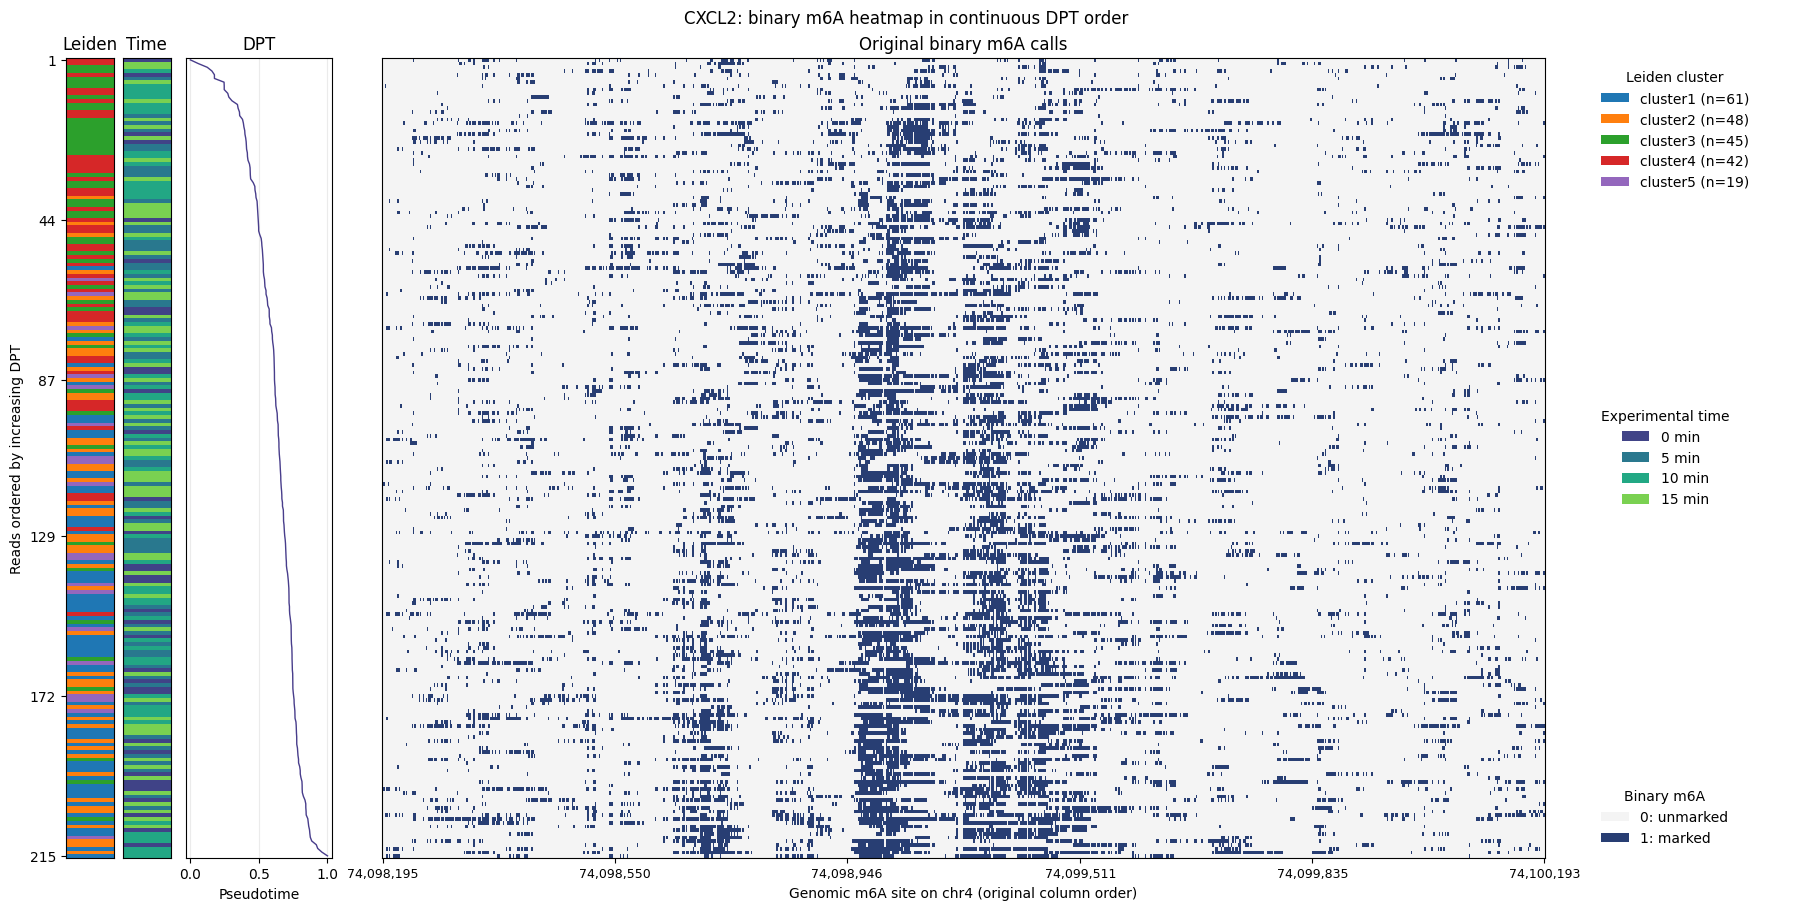

In [24]:
dpt_heat_obs = dpt_plot_obs.iloc[dpt_global_heatmap_order]
dpt_heat_values = dpt_plot_X[dpt_global_heatmap_order, :]
dpt_heat_rows = np.arange(len(dpt_heat_obs))
dpt_heat_cluster_codes = pd.Categorical(
    dpt_heat_obs["cluster"], categories=dpt_plot_cluster_levels
).codes
dpt_heat_time_codes = pd.Categorical(
    dpt_heat_obs["timepoint"], categories=dpt_plot_time_levels, ordered=True
).codes
dpt_heat_positions = adata.var["position"].to_numpy()
dpt_heat_ticks = np.unique(np.linspace(0, adata.n_vars - 1, 6).round().astype(int))

dpt_continuous_heatmap_fig = plt.figure(figsize=(18, 9), layout="constrained")
dpt_heat_grid = dpt_continuous_heatmap_fig.add_gridspec(
    1, 5, width_ratios=[0.5, 0.5, 1.5, 12, 2.2]
)
dpt_heat_cluster_ax = dpt_continuous_heatmap_fig.add_subplot(dpt_heat_grid[0, 0])
dpt_heat_time_ax = dpt_continuous_heatmap_fig.add_subplot(
    dpt_heat_grid[0, 1], sharey=dpt_heat_cluster_ax)
dpt_heat_score_ax = dpt_continuous_heatmap_fig.add_subplot(
    dpt_heat_grid[0, 2], sharey=dpt_heat_cluster_ax)
dpt_heat_matrix_ax = dpt_continuous_heatmap_fig.add_subplot(
    dpt_heat_grid[0, 3], sharey=dpt_heat_cluster_ax)
dpt_heat_legend_ax = dpt_continuous_heatmap_fig.add_subplot(dpt_heat_grid[0, 4])

dpt_heat_cluster_ax.imshow(
    dpt_heat_cluster_codes[:, None], aspect="auto", interpolation="nearest", origin="upper",
    cmap=ListedColormap(dpt_plot_cluster_colors), vmin=-0.5,
    vmax=len(dpt_plot_cluster_levels) - 0.5
)
dpt_heat_cluster_ax.set(title="Leiden", xticks=[], ylabel="Reads ordered by increasing DPT")
dpt_heat_row_ticks = np.unique(np.linspace(0, adata.n_obs - 1, 6).round().astype(int))
dpt_heat_cluster_ax.set_yticks(dpt_heat_row_ticks, labels=dpt_heat_row_ticks + 1)

dpt_heat_time_ax.imshow(
    dpt_heat_time_codes[:, None], aspect="auto", interpolation="nearest", origin="upper",
    cmap=ListedColormap(dpt_plot_time_colors), vmin=-0.5, vmax=len(dpt_plot_time_levels) - 0.5
)
dpt_heat_time_ax.set(title="Time", xticks=[])
dpt_heat_time_ax.tick_params(axis="y", left=False, labelleft=False)

dpt_heat_score_ax.plot(
    dpt_heat_obs["dpt_pseudotime"], dpt_heat_rows, color="darkslateblue", linewidth=1
)
dpt_heat_score_ax.set(title="DPT", xlabel="Pseudotime", xlim=(-0.03, 1.03), xticks=[0, 0.5, 1])
dpt_heat_score_ax.tick_params(axis="y", left=False, labelleft=False)
dpt_heat_score_ax.grid(axis="x", alpha=0.25)

dpt_heat_matrix_ax.imshow(
    dpt_heat_values, aspect="auto", interpolation="nearest", origin="upper",
    cmap=ListedColormap(dpt_binary_colors), vmin=0, vmax=1
)
dpt_heat_matrix_ax.set(
    title="Original binary m6A calls",
    xlabel=f"Genomic m6A site on {adata.var['chr'].iloc[0]} (original column order)"
)
dpt_heat_matrix_ax.set_xticks(
    dpt_heat_ticks, labels=[f"{int(dpt_heat_positions[i]):,}" for i in dpt_heat_ticks]
)
dpt_heat_matrix_ax.tick_params(axis="x", labelsize=9)
dpt_heat_matrix_ax.tick_params(axis="y", left=False, labelleft=False)
dpt_heat_cluster_ax.set_ylim(adata.n_obs - 0.5, -0.5)

dpt_heat_legend_ax.axis("off")
dpt_heat_cluster_legend = dpt_heat_legend_ax.legend(
    handles=[Patch(facecolor=dpt_plot_cluster_palette[c],
                   label=f"{c} (n={int(dpt_plot_obs['cluster'].eq(c).sum())})")
             for c in dpt_plot_cluster_levels],
    title="Leiden cluster", loc="upper left", frameon=False
)
dpt_heat_legend_ax.add_artist(dpt_heat_cluster_legend)
dpt_heat_time_legend = dpt_heat_legend_ax.legend(
    handles=[Patch(facecolor=color, label=f"{t} min")
             for t, color in zip(dpt_plot_time_levels, dpt_plot_time_colors)],
    title="Experimental time", loc="center left", frameon=False
)
dpt_heat_legend_ax.add_artist(dpt_heat_time_legend)
dpt_heat_legend_ax.legend(
    handles=[Patch(facecolor=color, label=label)
             for color, label in zip(dpt_binary_colors, ["0: unmarked", "1: marked"])],
    title="Binary m6A", loc="lower left", frameon=False
)
dpt_continuous_heatmap_fig.suptitle("CXCL2: binary m6A heatmap in continuous DPT order")
dpt_continuous_heatmap_pdf = dpt_figure_dir / "01_binary_m6a_continuous_DPT_heatmap.pdf"
dpt_continuous_heatmap_fig.savefig(dpt_continuous_heatmap_pdf, format="pdf", bbox_inches="tight")
plt.show()
print(f"Saved: {dpt_continuous_heatmap_pdf}")


### Read-level accessibility along DPT within each Leiden cluster

Each point is one read's mean binary m6A signal across all 827 original sites, plotted against its actual DPT score. Panels share the same DPT and accessibility axes; pseudotime is not rescaled within clusters.

Lines are descriptive LOWESS fits using a fixed 60% neighborhood (frac = 0.6, it = 0) within each cluster. Fits are evaluated only at observed DPT values, without extrapolation beyond that cluster's range. They summarize accessibility and do not infer a new trajectory. Raw points show the data supporting each fit; no confidence bands are implied.

Saved: /project/spott/cshan/fiber-seq/macrophage_project/pseudotime/DPT_CXCL2/figures/02_accessibility_over_DPT_by_Leiden_cluster.pdf


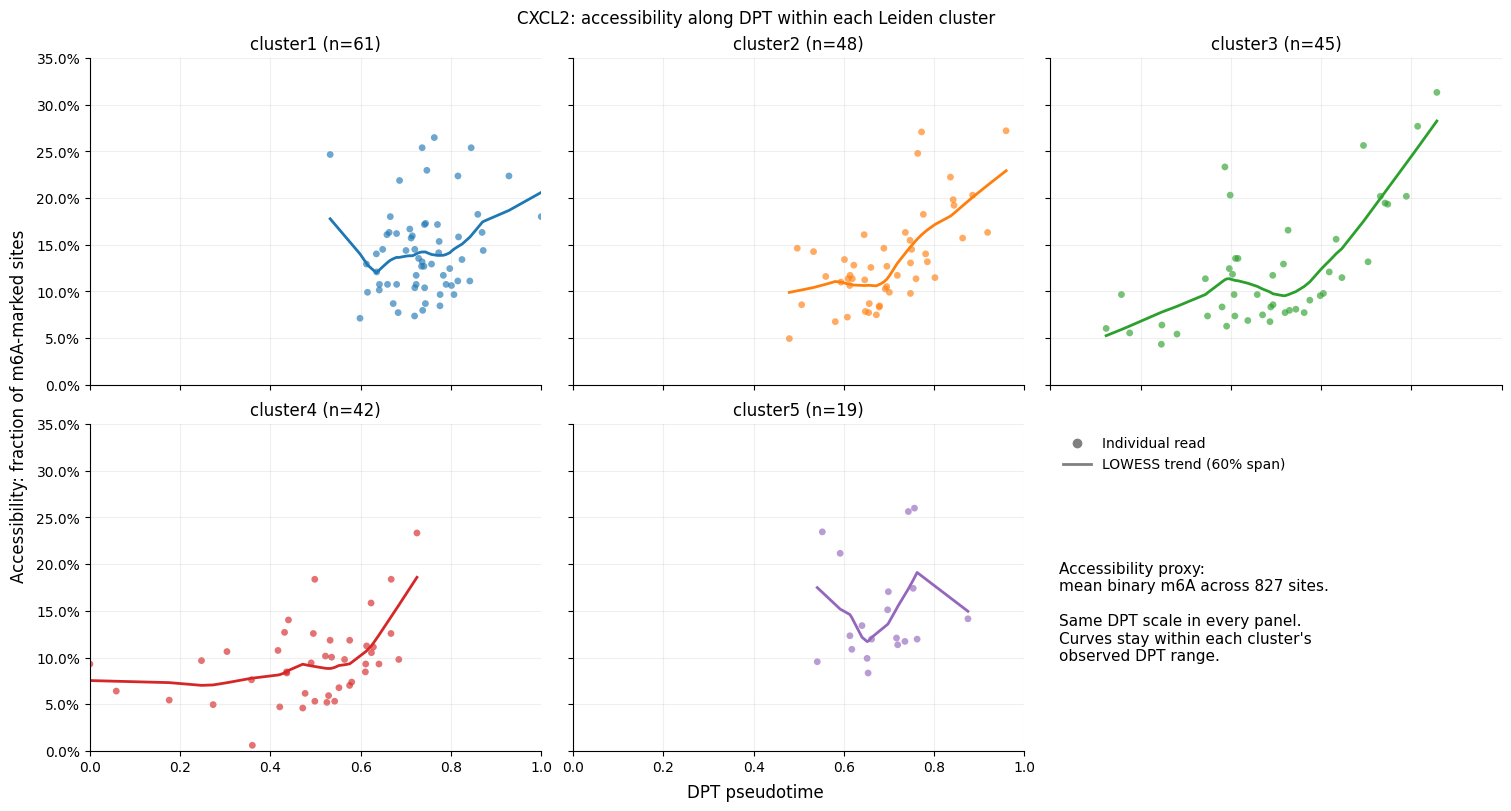

In [25]:
dpt_accessibility_fig, dpt_accessibility_axes = plt.subplots(
    2, 3, figsize=(15, 8), sharex=True, sharey=True, layout="constrained"
)
dpt_accessibility_axes = dpt_accessibility_axes.ravel()
dpt_accessibility_ymax = min(1.0, np.ceil(dpt_plot_obs["mean_m6a"].max() * 20) / 20)
dpt_accessibility_smooth = {}
dpt_accessibility_plotted_reads = 0

for ax, cluster in zip(dpt_accessibility_axes, dpt_plot_cluster_levels):
    cluster_reads = dpt_plot_obs.loc[dpt_plot_obs["cluster"].eq(cluster)].sort_values(
        ["dpt_pseudotime", "RID"], kind="stable"
    )
    color = dpt_plot_cluster_palette[cluster]
    ax.scatter(
        cluster_reads["dpt_pseudotime"], cluster_reads["mean_m6a"],
        s=24, color=color, alpha=0.65, edgecolors="none"
    )
    dpt_accessibility_plotted_reads += len(cluster_reads)
    if cluster_reads["dpt_pseudotime"].nunique() >= 3:
        trend = lowess(
            cluster_reads["mean_m6a"].to_numpy(),
            cluster_reads["dpt_pseudotime"].to_numpy(),
            frac=0.6, it=0, is_sorted=True, return_sorted=True, missing="raise"
        )
        dpt_accessibility_smooth[str(cluster)] = trend
        ax.plot(trend[:, 0], trend[:, 1], color=color, linewidth=2)
    ax.set(
        title=f"{cluster} (n={len(cluster_reads)})",
        xlim=(0, 1), ylim=(0, dpt_accessibility_ymax)
    )
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    ax.grid(alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)

assert dpt_accessibility_plotted_reads == adata.n_obs
for ax in dpt_accessibility_axes[len(dpt_plot_cluster_levels):]:
    ax.axis("off")
dpt_accessibility_key_ax = dpt_accessibility_axes[-1]
dpt_accessibility_key_ax.legend(
    handles=[
        Line2D([], [], marker="o", linestyle="none", color="gray", markersize=6,
               label="Individual read"),
        Line2D([], [], color="gray", linewidth=2, label="LOWESS trend (60% span)")
    ],
    loc="upper left", frameon=False
)
dpt_accessibility_key_ax.text(
    0.02, 0.58,
    "Accessibility proxy:\nmean binary m6A across 827 sites.\n\n"
    "Same DPT scale in every panel.\nCurves stay within each cluster's\nobserved DPT range.",
    transform=dpt_accessibility_key_ax.transAxes, va="top", fontsize=11
)
dpt_accessibility_fig.supxlabel("DPT pseudotime")
dpt_accessibility_fig.supylabel("Accessibility: fraction of m6A-marked sites")
dpt_accessibility_fig.suptitle("CXCL2: accessibility along DPT within each Leiden cluster")
dpt_accessibility_pdf = dpt_figure_dir / "02_accessibility_over_DPT_by_Leiden_cluster.pdf"
dpt_accessibility_fig.savefig(dpt_accessibility_pdf, format="pdf", bbox_inches="tight")
plt.show()
print(f"Saved: {dpt_accessibility_pdf}")
